# Vision-TransFormer Tutorial

- Tutorial: https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/11-vision-transformer.html
- Requirements: `numpy seaborn torch torchvision tensorboard torchmetrics matplotlib pytorch-lightning`

## Hand-made Packages

In [1]:
#%load_ext autoreload
#%autoreload 2
import os, sys
import time
#sys.path.insert(0, '../lib_vistf_hong_v1')
#import lib_vistf_hong_v1 as mylib

**%load_ext autoreload**
- It loads the autoreload extension, which allows you to automatically reload modules before executing code.
- Useful during development, so changes to your module are picked up without restarting the kernel.

**%autoreload 2**
- Enables automatic reloading of all imported modules every time a cell is run.
- `2` means: reload all modules (except those excluded by IPython).
- Helpful when you're editing your custom library in parallel — no need to restart the kernel.

## Basic Packages

In [2]:
import pandas as pd
import numpy  as np
#from pytorch_tabnet.tab_model import TabNetRegressor
#from sklearn.model_selection import KFold
from tqdm import tqdm
import glob

In [3]:
import os
import urllib.request
from urllib.error import HTTPError

import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [4]:
# Basic Settings for matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["mathtext.fontset"] = "stix"
plt.set_cmap("cividis")
%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")  # For export
matplotlib.rcParams["lines.linewidth"] = 2.0
sns.reset_orig()

<Figure size 640x480 with 0 Axes>

In [5]:
%load_ext tensorboard
# I will not use tensorboard .. though..

In [6]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


In [7]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [8]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-24449304-a305-dbe0-a5c8-bc765274bece)
GPU 1: NVIDIA GeForce RTX 3090 (UUID: GPU-1761614d-0d31-5a98-6d73-e9cabf8b877a)


### Data and CheckPoint Directories

In [9]:
pwdir = %pwd
print(pwdir)

/app/vistf/tutorial


In [10]:
%ls 

checkpoints/  tutorial-clf-vistf-v1.ipynb
data/         tutorial-clf-vistf-v2-2xgpu.ipynb


In [11]:
# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)
DATASET_PATH = '/app/vistf/tutorial/data/'
# Path to the folder where the pretrained models are saved
CHECKPOINT_ROOT = '/app/vistf/tutorial/checkpoints/'

#### Checkpoints for each training

In [12]:
from time import gmtime, strftime

base_name = 'tutorial_results'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take1'
experiment_name = f"{base_name}_{try_name}"
print("experiment:", experiment_name)

experiment: tutorial_results_take1


In [13]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")


⚠️ Directory exists: /app/vistf/tutorial/checkpoints/tutorial_results_take1
🧹 Removing all contents...
✅ Directory has been cleared.
📂 Experiment directory is ready: /app/vistf/tutorial/checkpoints/tutorial_results_take1


## Download pretrained data 

> Download the pre-trained model if you like to check .. but I will train the model by myself

## Read, Explore and Load Data

In [14]:
test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784]),
    ]
)
# For training, we add some augmentation. Networks are too powerful and would overfit.
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784]),
    ]
)

In [15]:
# Loading the training dataset. We need to split it into a training and validation part
# We need to do a little trick because the validation set should not use the augmentation.
train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=train_transform, download=True)
val_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=test_transform, download=True)
pl.seed_everything(42)
train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
pl.seed_everything(42)
_, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])

# Loading the test set
test_set = CIFAR10(root=DATASET_PATH, train=False, transform=test_transform, download=True)

Files already downloaded and verified
Files already downloaded and verified


Seed set to 42
Seed set to 42


Files already downloaded and verified


In [16]:
# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, \
                               pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

#### Visualize the training set 

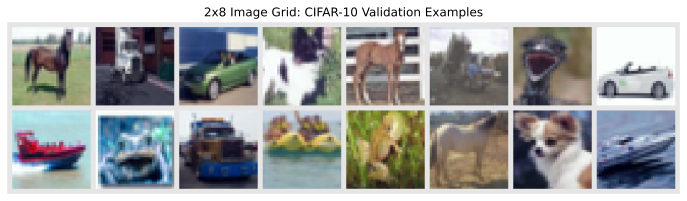

In [17]:
import matplotlib.pyplot as plt
import torchvision
import torch

# Parameters
ROWS = 2
COLS = 8
NUM_IMAGES = ROWS * COLS

# Stack selected images
CIFAR_images = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)

# Create grid: nrow=COLS controls how many images per row
img_grid = torchvision.utils.make_grid(CIFAR_images, nrow=COLS, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)  # Convert CHW to HWC for imshow

# Plotting
plt.figure(figsize=(COLS * 1.55, ROWS * 1.55))  # Scale figure size to number of images
plt.title("2x8 Image Grid: CIFAR-10 Validation Examples")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

# Vision Transformer for image classification

#### Image Patches

> First, let’s implement the image preprocessing: an image of size $N \times N$ has to be <br>
> split into $(N/M)^2$ patches of size $M \times M$. These represent the input words to the Transformer.

In [18]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Args:
        x: Tensor representing the image of shape [B, C, H, W]
        patch_size: Number of pixels per dimension of the patches (integer)
        flatten_channels: If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W]
    x = x.flatten(1, 2)  # [B, H'*W', C, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2, 4)  # [B, H'*W', C*p_H*p_W]
    return x

In [19]:
# Stack selected images
val_images = torch.stack([val_set[idx][0] for idx in range(16)], dim=0)

In [20]:
img_patches = img_to_patch(val_images, patch_size=4, flatten_channels=False)

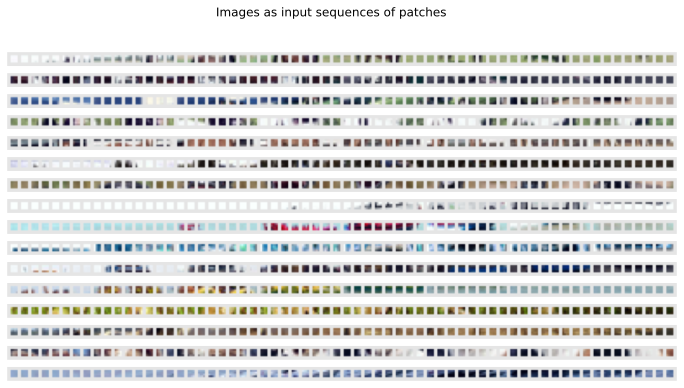

In [21]:
fig, ax = plt.subplots(val_images.shape[0], 1, figsize=(12, 6))
fig.suptitle("Images as input sequences of patches")
for i in range(val_images.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=64, normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis("off")
plt.show()
plt.close()

#### Transformer Block with Pre-Layer Normalization 

In [22]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=False)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.last_attn_weights = None  # 🆕 store attention weights here

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        #attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x, need_weights=True)
        attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x,need_weights=True, \
                                           average_attn_weights=False)  # 🧠 retain all heads!        
        self.last_attn_weights = attn_weights  # 🆕 save for inspection

        x = x + attn_out
        x = x + self.linear(self.layer_norm_2(x))
        return x

#### Wrapped-up Vision Transformer

In [23]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
    ):
        """Vision Transformer.

        Args:
            embed_dim: Dimensionality of the input feature vectors to the Transformer
            hidden_dim: Dimensionality of the hidden layer in the feed-forward networks
                         within the Transformer
            num_channels: Number of channels of the input (3 for RGB)
            num_heads: Number of heads to use in the Multi-Head Attention block
            num_layers: Number of layers to use in the Transformer
            num_classes: Number of classes to predict
            patch_size: Number of pixels that the patches have per dimension
            num_patches: Maximum number of patches an image can have
            dropout: Amount of dropout to apply in the feed-forward network and
                      on the input encoding

        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embedding[:, : T + 1]

        # Apply Transforrmer
        x = self.dropout(x)
        x = x.transpose(0, 1)
        x = self.transformer(x)

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

In [24]:
class ViT(pl.LightningModule):
    def __init__(self, model_kwargs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(**model_kwargs)
        self.example_input_array = next(iter(train_loader))[0]

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr)
        lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [lr_scheduler]

    def _calculate_loss(self, batch, mode="train"):
        imgs, labels = batch
        preds = self.model(imgs)
        loss = F.cross_entropy(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        self.log(f"{mode}_loss", loss)
        self.log(f"{mode}_acc", acc)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._calculate_loss(batch, mode="train")
        return loss

    def validation_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="val")

    def test_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="test")

## Model Fits

In [25]:
import time
from pytorch_lightning.callbacks import Callback

class MetricTracker(Callback):
    def __init__(self, cooldown_every_n_epochs=5, cooldown_seconds=5):
        # Tracking metrics
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []

        # Cooldown settings
        self.cooldown_every_n_epochs = cooldown_every_n_epochs
        self.cooldown_seconds = cooldown_seconds

    # ------------------------------
    # Metric collection
    # ------------------------------
    def on_validation_end(self, trainer, pl_module):
        # Skip sanity check validation
        if trainer.sanity_checking:
            return
            
        logs = trainer.callback_metrics

        val_loss = logs["val_loss"].item()
        val_acc = logs["val_acc"].item()

        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)

        current_epoch = trainer.current_epoch

        # ✅ Clean summary output
        print(f"✅ Epoch {current_epoch:03d} — val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    def on_train_epoch_end(self, trainer, pl_module, unused=None):
        logs = trainer.callback_metrics

        if "train_loss" in logs and "train_acc" in logs:
            self.train_loss.append(logs["train_loss"].item())
            self.train_acc.append(logs["train_acc"].item())

        # 🧊 Cooldown logic
        current_epoch = trainer.current_epoch
        if self.cooldown_every_n_epochs and current_epoch > 0:
            if current_epoch % self.cooldown_every_n_epochs == 0:
                print("== 🔥 GPU Cooling Break 🔥 ==")
                print(f"🧊 Cooling down after epoch {current_epoch}... sleeping for {self.cooldown_seconds} seconds.")
                time.sleep(self.cooldown_seconds)

    # ------------------------------
    # Disable progress bars (completely) ; though this block is not working .. 
    # ------------------------------
    def on_fit_start(self, trainer, pl_module):
        trainer.enable_progress_bar = False

    def on_validation_epoch_start(self, trainer, pl_module):
        trainer.enable_progress_bar = False

    def on_validation_epoch_end(self, trainer, pl_module):
        trainer.enable_progress_bar = False  # Keep it off

In [26]:
from pytorch_lightning.loggers import CSVLogger

def train_model(**kwargs):
    #metric_tracker = MetricTracker()
    metric_tracker = MetricTracker(cooldown_every_n_epochs=5,cooldown_seconds=5)

    # Get user-defined checkpoints_dir or fallback to CHECKPOINT_PATH
    checkpoints_dir = kwargs.pop("mycheckpoints", CHECKPOINT_PATH)
    max_epochs = kwargs.pop("max_epochs", 180)  # 👈 default to 180 if not provided
    vit_dir = os.path.join(checkpoints_dir, "ViT")

    # Add a lightweight CSV logger
    logger = CSVLogger(save_dir=checkpoints_dir, name="ViT_logs")

    trainer = pl.Trainer(
        default_root_dir=vit_dir,
        accelerator="auto",
        devices=1,
        max_epochs=max_epochs,
        enable_progress_bar=False,  # ⛔ disables all tqdm bars including validation
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),
            LearningRateMonitor("epoch"),
            metric_tracker,
        ],
        logger=logger,  # ✅ Now using CSVLogger
    )

    pretrained_filename = os.path.join(checkpoints_dir, "ViT.ckpt")
    if os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = ViT.load_from_checkpoint(pretrained_filename)
    else:
        pl.seed_everything(42)
        model = ViT(**kwargs)
        trainer.fit(model, train_loader, val_loader)
        model = ViT.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

    # Temporarily disable progress bar for validation/test
    trainer.enable_progress_bar = False
    
    val_result = trainer.test(model, dataloaders=val_loader, verbose=False)
    test_result = trainer.test(model, dataloaders=test_loader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result, metric_tracker

In [ ]:
%%time
model, results, tracker = train_model(
    model_kwargs={
        "embed_dim": 256,
        "hidden_dim": 512,
        "num_heads": 8,
        "num_layers": 6,
        "patch_size": 4,
        "num_channels": 3,
        "num_patches": 64,
        "num_classes": 10,
        "dropout": 0.2,
    },
    lr=3e-4,
    max_epochs=100,
    #mycheckpoints=checkpoints_dir
)
print("ViT results", results)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 42
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type              | Params | Mode  | In sizes         | Out sizes
-----------------------------------------------------------------------------------
0 | model | VisionTransformer | 3.2 M  | train | [128, 3, 32, 32] | [128, 10]
-----------------------------------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.781    Total estimated model params size (MB)
73    

✅ Epoch 000 — val_loss: 1.4397 | val_acc: 0.4814
✅ Epoch 001 — val_loss: 1.3121 | val_acc: 0.5316
✅ Epoch 002 — val_loss: 1.1925 | val_acc: 0.5742
✅ Epoch 003 — val_loss: 1.1627 | val_acc: 0.5858
✅ Epoch 004 — val_loss: 1.1033 | val_acc: 0.6136
✅ Epoch 005 — val_loss: 1.0748 | val_acc: 0.6112
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down after epoch 5... sleeping for 5 seconds.
✅ Epoch 006 — val_loss: 1.0417 | val_acc: 0.6236
✅ Epoch 007 — val_loss: 1.0308 | val_acc: 0.6324
✅ Epoch 008 — val_loss: 1.0262 | val_acc: 0.6482
✅ Epoch 009 — val_loss: 0.9624 | val_acc: 0.6632
✅ Epoch 010 — val_loss: 0.9744 | val_acc: 0.6612
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down after epoch 10... sleeping for 5 seconds.
✅ Epoch 011 — val_loss: 0.9512 | val_acc: 0.6666
✅ Epoch 012 — val_loss: 0.9478 | val_acc: 0.6708
✅ Epoch 013 — val_loss: 0.9226 | val_acc: 0.6790
✅ Epoch 014 — val_loss: 0.9153 | val_acc: 0.6836
✅ Epoch 015 — val_loss: 0.9237 | val_acc: 0.6762
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down afte

In [31]:
print("ViT results", results)

ViT results {'test': 0.72079998254776, 'val': 0.7160000205039978}


In [32]:
print("ViT results", tracker)
print(f"Train Loss: {len(tracker.train_loss)}")
print(f"Val Loss:   {len(tracker.val_loss)}")

ViT results <__main__.MetricTracker object at 0x7fe613931660>
Train Loss: 30
Val Loss:   30


In [33]:
import matplotlib.pyplot as plt
import matplotlib

def plot_metrics(metrics):
    # 🖋️ Set global font settings
    matplotlib.rcParams["font.family"] = "serif"
    matplotlib.rcParams["mathtext.fontset"] = "stix"

    # Gather metric lengths
    train_len = len(metrics.train_loss)
    val_len = len(metrics.val_loss)
    min_len = min(train_len, val_len)

    if min_len == 0:
        print("⚠️ No metric data to plot.")
        return

    # Create matching epoch indices
    epochs = list(range(1, min_len + 1))

    # Slice to sync lengths
    train_loss = metrics.train_loss[:min_len]
    val_loss = metrics.val_loss[:min_len]
    train_acc = metrics.train_acc[:min_len]
    val_acc = metrics.val_acc[:min_len]

    # Check for flat data
    def is_constant(data):
        return all(x == data[0] for x in data)

    # Begin plotting
    plt.figure(figsize=(9, 4))

    # 🔹 Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Val Loss', marker='x')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    if is_constant(train_loss + val_loss):
        print("⚠️ Loss values are constant — check your training loop.")

    # 🔸 Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Acc', marker='o')
    plt.plot(epochs, val_acc, label='Val Acc', marker='x')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    if is_constant(train_acc + val_acc):
        print("⚠️ Accuracy values are constant — check your logging or model performance.")

    plt.tight_layout()
    plt.show()

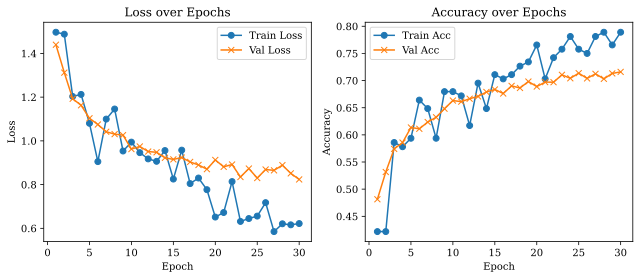

In [34]:
plot_metrics(tracker)

## Predictions and Performance Evaluations

#### Where the output log is 

In [35]:
resultsroot = CHECKPOINT_PATH+'/ViT_logs/'
print(resultsroot)

/app/vistf/tutorial/checkpoints/tutorial_results_take1/ViT_logs/


In [36]:
resultsdir = !ls {resultsroot}
print(resultsdir)

['version_0']


In [37]:
%ls {resultsroot+resultsdir[0]}

checkpoints/  hparams.yaml  metrics.csv


In [38]:
modelname = !ls {resultsroot+resultsdir[0]+'/checkpoints/'}
print(modelname)

['epoch=29-step=10530.ckpt']


In [39]:
resultsroot+resultsdir[0]+'/checkpoints/'+modelname[0]

'/app/vistf/tutorial/checkpoints/tutorial_results_take1/ViT_logs/version_0/checkpoints/epoch=29-step=10530.ckpt'

## Predictions

In [40]:
import torch

def predict(model, dataloader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    # Concatenate all batches into single tensors
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    return all_preds, all_labels

In [41]:
preds, labels = predict(model, test_loader)

In [42]:
# Example: show 10 predictions
print("Predicted:", preds[:10].tolist())
print("Ground truth:", labels[:10].tolist())

Predicted: [3, 8, 0, 8, 6, 6, 3, 6, 5, 1]
Ground truth: [3, 8, 8, 0, 6, 6, 1, 6, 3, 1]


In [43]:
import torch
import torch.nn.functional as F

def predict_prob(model, dataloader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)

    return all_preds, all_probs, all_labels

In [44]:
preds, probs, labels = predict_prob(model, test_loader)

In [45]:
print("Preds: ", preds[:3].tolist())
print("Labels:", labels[:3].tolist())
print("Probs: ", probs[:3].tolist())  # shape: [5, num_classes]

Preds:  [3, 8, 0]
Labels: [3, 8, 8]
Probs:  [[0.037268951535224915, 9.165129449684173e-05, 0.003424322698265314, 0.8960738778114319, 0.006520045455545187, 0.037499576807022095, 0.0003543874772731215, 0.006926791742444038, 0.011711222119629383, 0.00012915761908516288], [9.434149251319468e-05, 0.0006597705651074648, 5.466766879180796e-07, 8.151979500325979e-07, 2.8000016527585103e-07, 9.177587685371691e-07, 5.334856041372404e-07, 5.610119728771679e-07, 0.999221682548523, 2.0628542188205756e-05], [0.5228834748268127, 0.047332968562841415, 0.0001329542137682438, 0.0005402327515184879, 0.0004945262335240841, 6.12880612607114e-05, 3.778138488996774e-05, 0.000519659835845232, 0.3139776289463043, 0.11401944607496262]]


## Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [47]:
def plot_confusion_matrix(preds, labels, class_names=None, normalize=True):
    cm = confusion_matrix(labels, preds)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    plt.show()

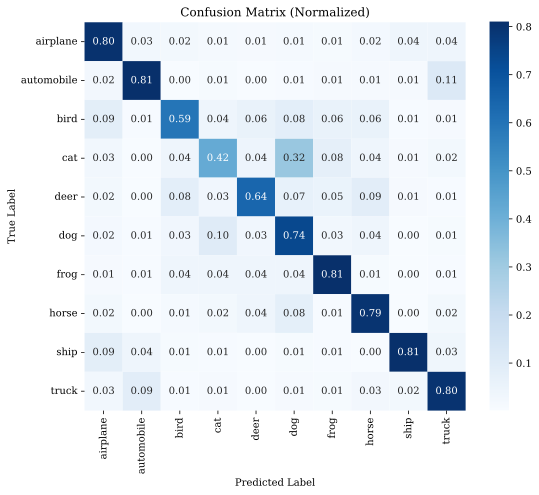

In [48]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plot_confusion_matrix(preds, labels, class_names=class_names)

## Attention Map

#### Test Images

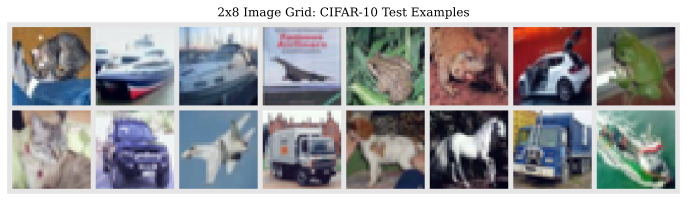

In [49]:
import matplotlib.pyplot as plt
import torchvision
import torch

# Parameters
ROWS = 2
COLS = 8
NUM_IMAGES = ROWS * COLS

# Stack selected images
test_images = torch.stack([test_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)

# Create grid: nrow=COLS controls how many images per row
img_grid = torchvision.utils.make_grid(test_images, nrow=COLS, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)  # Convert CHW to HWC for imshow

# Plotting
plt.figure(figsize=(COLS * 1.55, ROWS * 1.55))  # Scale figure size to number of images
plt.title("2x8 Image Grid: CIFAR-10 Test Examples")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

#### Attention Map

In [50]:
def get_last_attn_map(model: VisionTransformer, x: torch.Tensor, patch_grid=(8, 8)) -> np.ndarray:
    """
    Extract the last CLS-to-patch attention map as a 2D NumPy array.
    Args:
        model: VisionTransformer instance
        x: image tensor [1, 3, H, W]
        patch_grid: expected (H', W') shape of the attention map

    Returns:
        np.ndarray: attention heatmap [H', W']
    """
    model.eval()
    with torch.no_grad():
        _ = model(x)  # run forward to populate attention

        # Fetch stored attention from final transformer block
        attn = model.transformer[-1].last_attn_weights  # [1, num_heads, tokens, tokens]
        attn_cls = attn.mean(dim=1)[:, 0, 1:]  # [1, num_patches]

        attn_2d = attn_cls.reshape(*patch_grid)
        return attn_2d.cpu().numpy()

In [51]:
img_tensor = test_set[0][0].unsqueeze(0).to(device)
attn_map_np = get_last_attn_map(model.model, img_tensor, patch_grid=(8, 8))

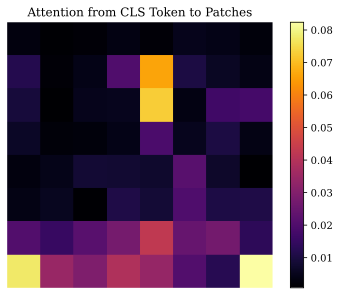

In [52]:
import matplotlib.pyplot as plt
plt.imshow(attn_map_np, cmap="inferno")
plt.colorbar()
plt.title("Attention from CLS Token to Patches")
plt.axis("off")
plt.show()

#### All in one Images 

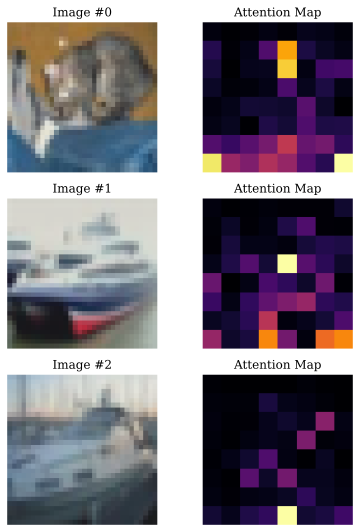

In [58]:
import matplotlib.pyplot as plt
import torch

# CIFAR-10 normalization (used in your `test_transform`)
# If you used something else, update these!
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)  # restore pixel values to [0, 1]

# Plotting 3 test images + attention maps
NUM_ROWS = 3
plt.figure(figsize=(6, NUM_ROWS * 2.5))

for i in range(NUM_ROWS):
    img_tensor = test_set[i][0]  # [3, 32, 32]
    img_batch = img_tensor.unsqueeze(0).to(device)  # [1, 3, 32, 32]

    # Get attention map
    attn_map_np = get_last_attn_map(model.model, img_batch, patch_grid=(8, 8))

    # --- Plot original image (left column) ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 1)
    img_vis = denormalize(img_tensor).permute(1, 2, 0).cpu().numpy()  # → [H, W, C]
    plt.imshow(img_vis)
    plt.title(f"Image #{i}")
    plt.axis("off")

    # --- Plot attention map (right column) ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 2)
    plt.imshow(attn_map_np, cmap="inferno", interpolation="nearest")
    plt.title("Attention Map")
    plt.axis("off")

plt.tight_layout()
plt.show()

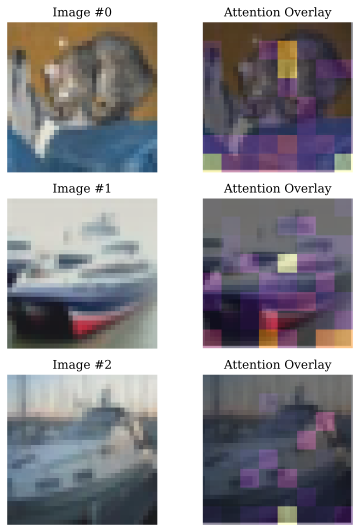

In [73]:
import matplotlib.pyplot as plt
import torch

# CIFAR-10 normalization parameters
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Plot 3 test images with sharp overlaid attention maps
NUM_ROWS = 3
plt.figure(figsize=(6, NUM_ROWS * 2.5))

for i in range(NUM_ROWS):
    img_tensor = test_set[i][0]
    img_batch = img_tensor.unsqueeze(0).to(device)

    # Get attention map
    attn_map_np = get_last_attn_map(model.model, img_batch, patch_grid=(8, 8))

    # Prepare image for display
    img_vis = denormalize(img_tensor).permute(1, 2, 0).cpu().numpy()

    # --- Left: original image ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 1)
    plt.imshow(img_vis) 
    plt.title(f"Image #{i}")
    plt.axis("off")
    
    # --- Right: attention map overlaid (preserve full-res background) ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 2)
    plt.imshow(img_vis, interpolation="nearest")  # show original 32x32 image
    plt.imshow(attn_map_np, cmap="inferno", alpha=0.7, interpolation="nearest", extent=[0, 32, 32, 0])  # map attention correctly
    plt.title("Attention Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()